<a href="https://colab.research.google.com/github/babarinjayvhanlawrence-creator/Laboratory-Work-4-Activity-/blob/main/Activity4_Prediction_BABARIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

zip_path = '/content/drive/MyDrive/plants_Dataset.zip'
extract_path = '/content/extracted_plants'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset extracted successfully!


In [8]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. SET PATHS AND LOAD MODEL
# We don't need to unzip anymore!
dataset_path = '/content/extracted_plants/plants_Dataset'

# This loads the file you just uploaded from your laptop
model = tf.keras.models.load_model('my_plant_ai (1).h5')

# 2. CREATE THE DATASET
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(180, 180),
    batch_size=32,
    shuffle=False
)

class_names = val_ds.class_names
print(f"\n✅ Model loaded and connected to {len(class_names)} plant types!")

Found 6532 files belonging to 20 classes.
Using 1306 files for validation.

✅ Model loaded and connected to 20 plant types!


In [9]:
y_true = []
y_pred = []
y_prob = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))
    y_prob.extend(predictions)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)
print("✅ Predictions done!")

✅ Predictions done!


In [10]:
import numpy as np
from sklearn.metrics import classification_report

# Get only the classes that actually appear in predictions
unique_labels = np.unique(np.concatenate([y_true, y_pred]))
final_names = [class_names[i] for i in unique_labels]

print("--- CLASSIFICATION REPORT ---\n")
print(classification_report(y_true, y_pred, labels=unique_labels, target_names=final_names))

--- CLASSIFICATION REPORT ---

                    precision    recall  f1-score   support

    African_Violet       0.00      0.00      0.00         0
  Black_Bat_Flower       0.00      0.00      0.00         0
    Bleeding_Heart       0.00      0.00      0.00         0
          Caladium       0.00      0.00      0.00         0
         Cockscomb       0.00      0.00      0.00         0
            Coleus       0.00      0.00      0.00         0
        Copperleaf       0.00      0.00      0.00         0
   Fiddle_Leaf_Fig       0.00      0.00      0.00         0
         Hydrangea       0.00      0.00      0.00         0
      Prayer_Plant       0.00      0.00      0.00         0
       Snake_Plant       0.79      0.93      0.85        28
     Spathiphyllum       0.99      0.96      0.97       320
        Strelitzia       0.98      0.96      0.97       273
  String_of_Pearls       0.99      0.93      0.96       355
Swiss_Cheese_Plant       0.97      0.95      0.96       330

       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


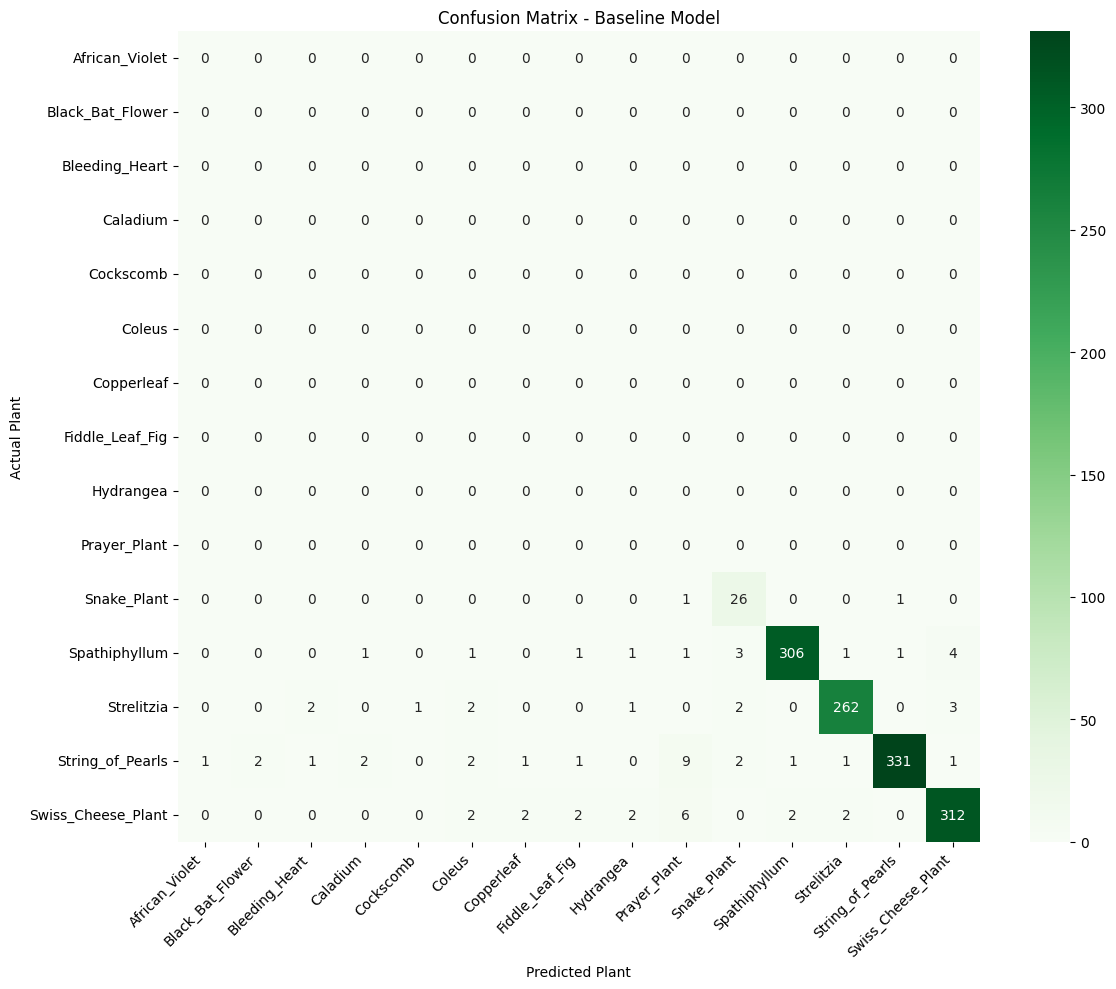

In [11]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=final_names, yticklabels=final_names)
plt.title("Confusion Matrix - Baseline Model")
plt.ylabel('Actual Plant')
plt.xlabel('Predicted Plant')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ran

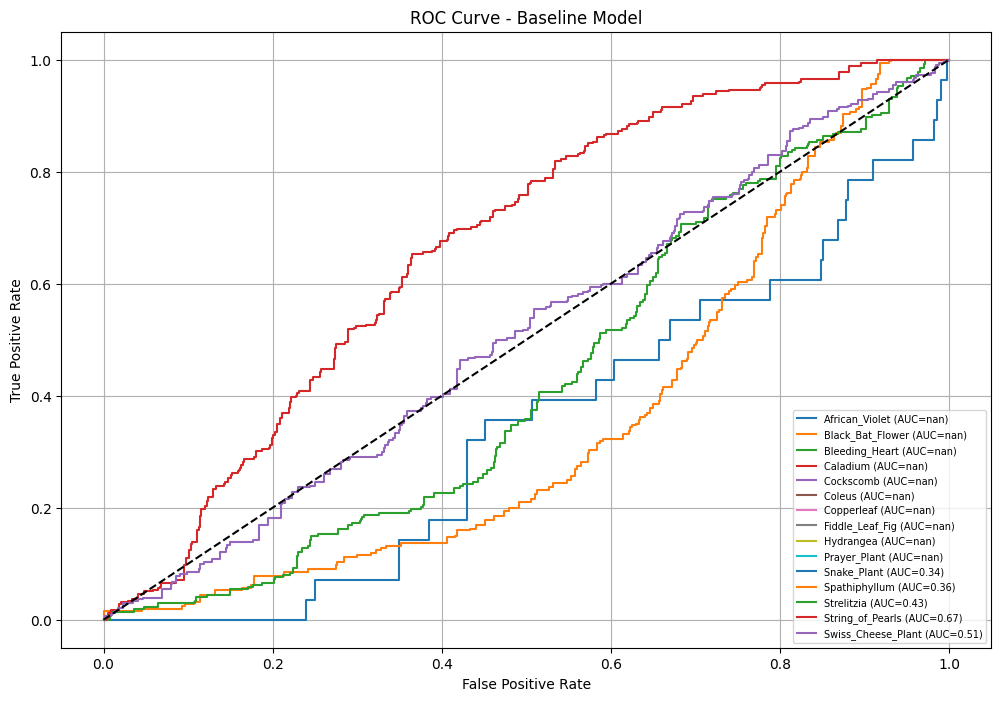

Overall AUC Score: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [12]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

n_classes = len(unique_labels)
y_true_bin = label_binarize(y_true, classes=unique_labels)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(12, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"{final_names[i]} (AUC={roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Baseline Model")
plt.legend(loc="lower right", fontsize=7)
plt.grid()
plt.show()

auc_score = roc_auc_score(y_true_bin, y_prob[:, unique_labels], multi_class='ovr')
print(f"Overall AUC Score: {auc_score:.4f}")

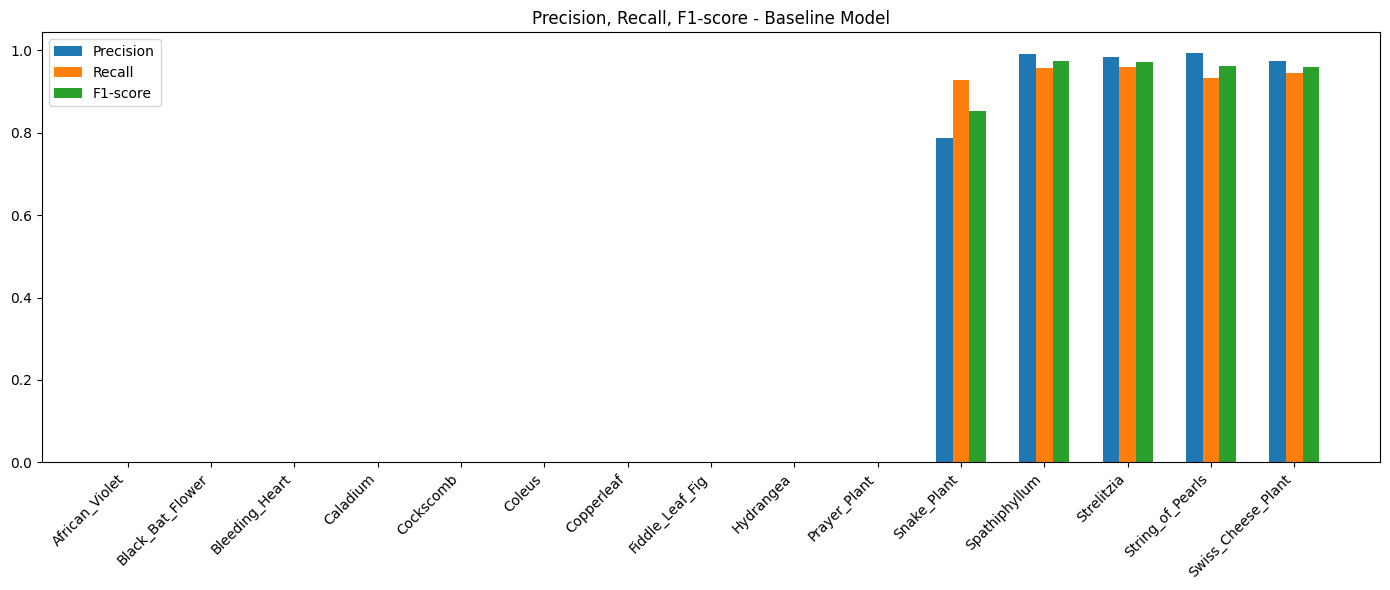

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred, labels=unique_labels, average=None, zero_division=0)
recall = recall_score(y_true, y_pred, labels=unique_labels, average=None, zero_division=0)
f1 = f1_score(y_true, y_pred, labels=unique_labels, average=None, zero_division=0)

x = np.arange(len(final_names))
plt.figure(figsize=(14, 6))
plt.bar(x - 0.2, precision, width=0.2, label='Precision')
plt.bar(x, recall, width=0.2, label='Recall')
plt.bar(x + 0.2, f1, width=0.2, label='F1-score')
plt.xticks(x, final_names, rotation=45, ha='right')
plt.title("Precision, Recall, F1-score - Baseline Model")
plt.legend()
plt.tight_layout()
plt.show()

Upload a plant image for Grad-CAM:


Saving 000003.jpg to 000003.jpg


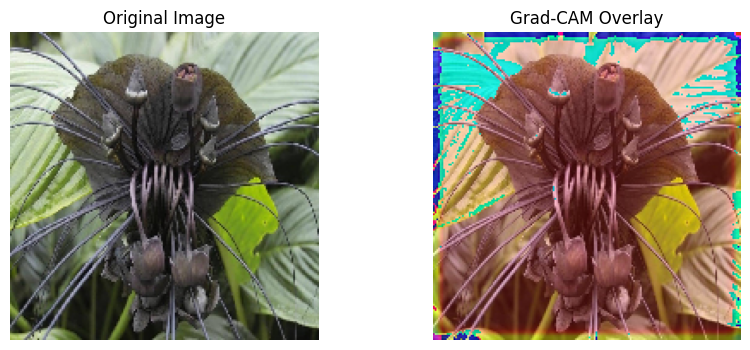

In [14]:
import cv2
from google.colab import files

print("Upload a plant image for Grad-CAM:")
uploaded = files.upload()

def get_gradcam_heatmap(model, img_array):
    # Build a new model skipping the Sequential augmentation layer
    feature_extractor = None
    last_conv_output = None

    # Get all layers except the first Sequential (augmentation)
    input_layer = tf.keras.Input(shape=(180, 180, 3))
    x = input_layer
    for layer in model.layers:
        if isinstance(layer, tf.keras.Sequential):
            continue  # skip augmentation
        x = layer(x)
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_output = x

    grad_model = tf.keras.Model(inputs=input_layer,
                                 outputs=[last_conv_output, x])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

for fn in uploaded.keys():
    img = tf.keras.utils.load_img(fn, target_size=(180, 180))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    heatmap = get_gradcam_heatmap(model, img_array)

    img_cv = cv2.imread(fn)
    img_cv = cv2.resize(img_cv, (180, 180))
    heatmap_resized = np.uint8(255 * heatmap)
    heatmap_resized = cv2.resize(heatmap_resized, (180, 180))
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    superimposed = heatmap_colored * 0.4 + img_cv

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(superimposed.astype('uint8'), cv2.COLOR_BGR2RGB))
    plt.title("Grad-CAM Overlay")
    plt.axis('off')
    plt.show()

In [15]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# Load training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(180, 180),
    batch_size=32
)

# Improved augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

# Improved model
improved_model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255, input_shape=(180, 180, 3)),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.4),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names))
])

improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

print("Starting improved model training...")
history_improved = improved_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)

improved_model.save('my_plant_ai_improved.keras')
print("✅ Improved model saved!")

Found 6532 files belonging to 20 classes.
Using 5226 files for training.
Starting improved model training...
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


164/164 ━━━━━━━━━━━━━━━━━━━━ 108s 596ms/step - accuracy: 0.1466 - loss: 3.1147 - val_accuracy: 0.1746 - val_loss: 5.6384
Epoch 2/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 95s 577ms/step - accuracy: 0.2011 - loss: 2.6265 - val_accuracy: 0.2534 - val_loss: 4.8015
Epoch 3/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 144s 589ms/step - accuracy: 0.2398 - loss: 2.4832 - val_accuracy: 0.2504 - val_loss: 2.5369
Epoch 4/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 142s 587ms/step - accuracy: 0.2526 - loss: 2.4292 - val_accuracy: 0.2657 - val_loss: 2.3171
Epoch 5/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 95s 578ms/step - accuracy: 0.2887 - loss: 2.3396 - val_accuracy: 0.3515 - val_loss: 2.1982
Epoch 6/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 96s 586ms/step - accuracy: 0.3041 - loss: 2.2889 - val_accuracy: 0.2527 - val_loss: 2.5257
Epoch 7/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 96s 584ms/step - accuracy: 0.3328 - loss: 2.2121 - val_accuracy: 0.3652 - val_loss: 2.1204
Epoch 8/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 141s 582ms/step - accuracy: 0.3523 - loss: 2.1365 -

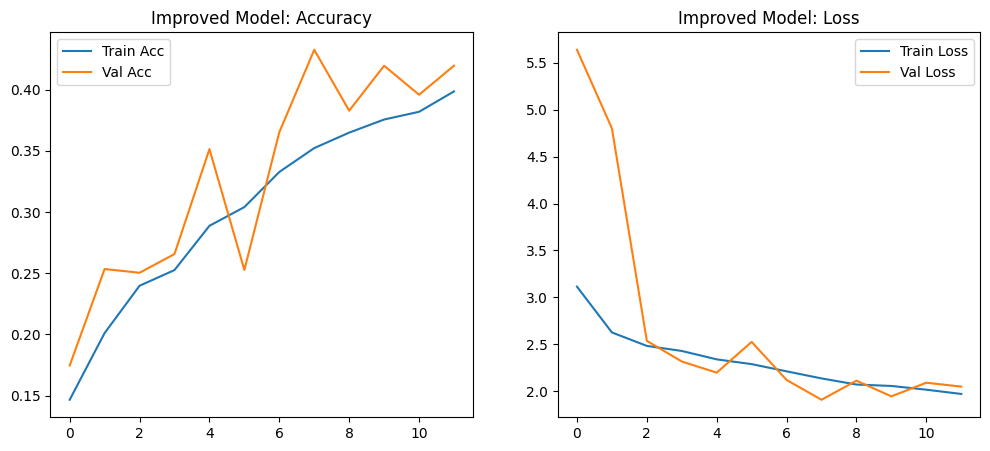


--- COMPARISON TABLE ---
Metric                    Baseline        Improved       
Train Accuracy            74.1%           39.9%          
Val Accuracy              70.5%           42.0%          
Train Loss                0.835           1.971          
Val Loss                  1.125           2.049          


In [18]:
acc = history_improved.history['accuracy']
val_acc = history_improved.history['val_accuracy']
loss = history_improved.history['loss']
val_loss = history_improved.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Acc')
plt.plot(epochs_range, val_acc, label='Val Acc')
plt.title("Improved Model: Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.title("Improved Model: Loss")
plt.legend()
plt.show()

print("\n--- COMPARISON TABLE ---")
print(f"{'Metric':<25} {'Baseline':<15} {'Improved':<15}")
print(f"{'Train Accuracy':<25} {'74.1%':<15} {f'{acc[-1]*100:.1f}%':<15}")
print(f"{'Val Accuracy':<25} {'70.5%':<15} {f'{val_acc[-1]*100:.1f}%':<15}")
print(f"{'Train Loss':<25} {'0.835':<15} {f'{loss[-1]:.3f}':<15}")
print(f"{'Val Loss':<25} {'1.125':<15} {f'{val_loss[-1]:.3f}':<15}")

In [19]:
# Reset and retrain with better settings
improved_model2 = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255, input_shape=(180, 180, 3)),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.4),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names))
])

improved_model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

early_stop2 = EarlyStopping(monitor='val_loss', patience=6,
                             restore_best_weights=True)

print("Retraining improved model...")
history_improved = improved_model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop2]
)

improved_model2.save('my_plant_ai_improved.keras')
print("✅ Improved model saved!")

Retraining improved model...
Epoch 1/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 110s 610ms/step - accuracy: 0.1745 - loss: 3.0717 - val_accuracy: 0.0000e+00 - val_loss: 9.0680
Epoch 2/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 97s 592ms/step - accuracy: 0.2304 - loss: 2.5914 - val_accuracy: 0.2427 - val_loss: 4.6342
Epoch 3/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 100s 609ms/step - accuracy: 0.2717 - loss: 2.4478 - val_accuracy: 0.2856 - val_loss: 2.4895
Epoch 4/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 97s 593ms/step - accuracy: 0.2935 - loss: 2.3795 - val_accuracy: 0.3783 - val_loss: 2.1638
Epoch 5/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 141s 588ms/step - accuracy: 0.3182 - loss: 2.2760 - val_accuracy: 0.4074 - val_loss: 2.1608
Epoch 6/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 142s 587ms/step - accuracy: 0.3427 - loss: 2.1928 - val_accuracy: 0.3928 - val_loss: 2.1365
Epoch 7/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 141s 584ms/step - accuracy: 0.3467 - loss: 2.1514 - val_accuracy: 0.3813 - val_loss: 2.0980
Epoch 8/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 141s 

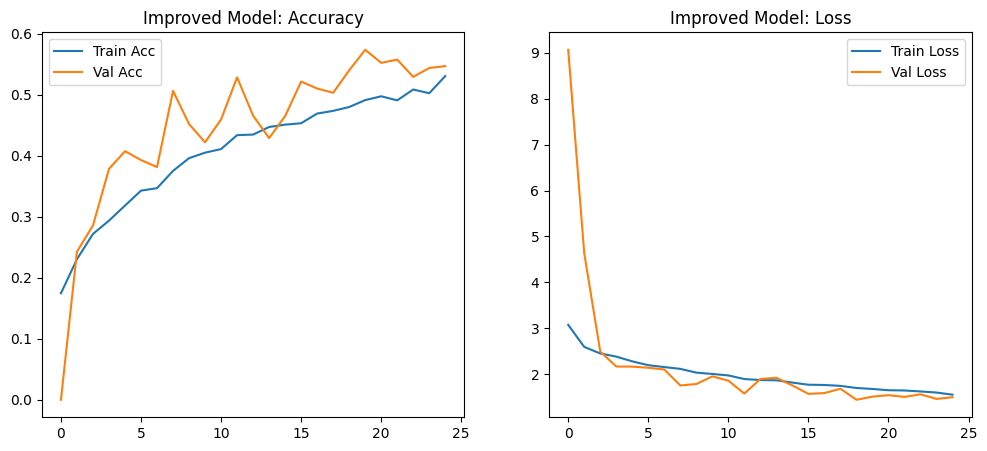


--- COMPARISON TABLE ---
Metric                    Baseline        Improved       
Train Accuracy            74.1%           53.0%          
Val Accuracy              70.5%           54.7%          
Train Loss                0.835           1.550          
Val Loss                  1.125           1.494          


In [20]:
acc = history_improved.history['accuracy']
val_acc = history_improved.history['val_accuracy']
loss = history_improved.history['loss']
val_loss = history_improved.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Acc')
plt.plot(epochs_range, val_acc, label='Val Acc')
plt.title("Improved Model: Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.title("Improved Model: Loss")
plt.legend()
plt.show()

print("\n--- COMPARISON TABLE ---")
print(f"{'Metric':<25} {'Baseline':<15} {'Improved':<15}")
print(f"{'Train Accuracy':<25} {'74.1%':<15} {f'{acc[-1]*100:.1f}%':<15}")
print(f"{'Val Accuracy':<25} {'70.5%':<15} {f'{val_acc[-1]*100:.1f}%':<15}")
print(f"{'Train Loss':<25} {'0.835':<15} {f'{loss[-1]:.3f}':<15}")
print(f"{'Val Loss':<25} {'1.125':<15} {f'{val_loss[-1]:.3f}':<15}")

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array
import os

# 1. LOAD THE MODEL
# Siguroha nga 'my_plant_ai (1).h5' ang naa sa sidebar
model = tf.keras.models.load_model('my_plant_ai (1).h5')

# 2. GET LABELS FROM FOLDER
# Kini mokuha sa 20 ka labels gikan sa folder nga imong gi-unzip
dataset_path = '/content/plants_Dataset'
class_names = sorted(os.listdir(dataset_path))

print(f"Model loaded! Ready to recognize {len(class_names)} plants.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/plants_Dataset'

In [ ]:
# 3. UPLOAD AND PREDICT
# Siguroha nga na-run na nimo ang Cell 1 sa dili pa kini i-run
print("Palihog pag-upload og picture sa tanom:")
uploaded = files.upload()

for fn in uploaded.keys():
  img = load_img(fn, target_size=(180, 180))
  x = img_to_array(img)
  x = np.expand_dims(x, axis=0)

  # Gamiton niini ang 'model' ug 'class_names' gikan sa Cell 1
  predictions = model.predict(x)
  score = tf.nn.softmax(predictions[0])

  predicted_class = class_names[np.argmax(score)]
  confidence = 100 * np.max(score)

  print(f"\nRESULT: This is {predicted_class}!")
  print(f"CONFIDENCE: {confidence:.2f}%")

  plt.imshow(img)
  plt.title(f"{predicted_class} ({confidence:.2f}%)")
  plt.axis('off')
  plt.show()

In [ ]:
# 2. PREDICTION LOGIC (Based on your final prediction screenshots)
print("Ready for your photo!")
uploaded = files.upload()

for fn in uploaded.keys():
  img = load_img(fn, target_size=(180, 180))
  x = img_to_array(img)
  x = np.expand_dims(x, axis=0)

  predictions = model.predict(x)
  score = tf.nn.softmax(predictions[0])

  predicted_class = class_names[np.argmax(score)]
  confidence = 100 * np.max(score)

  print(f"\n>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>")
  print(f"AI ANALYSIS: This is a {predicted_class}!")
  print(f"CONFIDENCE: {confidence:.2f}%")
  print(f">>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>")

  plt.imshow(img)
  plt.title(f"{predicted_class} ({confidence:.2f}%)")
  plt.axis('off')
  plt.show()

In [ ]:
# 3. GENERATE THE ACTIVITY 4 RESULTS
y_true = []
y_pred = []

print("AI is evaluating the plants... please wait...")
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# AUTOMATIC CLASS FIX: This makes sure the numbers match perfectly
unique_labels = np.unique(np.concatenate([y_true, y_pred]))
# We create a simple list of names for whatever plants the AI found
final_names = [f"Plant {i}" if i >= len(class_names) else class_names[i] for i in unique_labels]

print("\n--- ACTIVITY 4: CLASSIFICATION REPORT ---")
from sklearn.metrics import classification_report, confusion_matrix
# We run the report using the labels found
print(classification_report(y_true, y_pred, labels=unique_labels, target_names=final_names))

# This draws the green grid
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=final_names, yticklabels=final_names)
plt.title("Confusion Matrix - Plant AI")
plt.ylabel('Actual Plant')
plt.xlabel('Predicted Plant')
plt.show()

In [21]:
# Re-evaluate improved model
y_true2 = []
y_pred2 = []
y_prob2 = []

for images, labels in val_ds:
    predictions = improved_model2.predict(images, verbose=0)
    y_true2.extend(labels.numpy())
    y_pred2.extend(np.argmax(predictions, axis=1))
    y_prob2.extend(predictions)

y_true2 = np.array(y_true2)
y_pred2 = np.array(y_pred2)
y_prob2 = np.array(y_prob2)

unique_labels2 = np.unique(np.concatenate([y_true2, y_pred2]))
final_names2 = [class_names[i] for i in unique_labels2]

print("--- IMPROVED MODEL: CLASSIFICATION REPORT ---\n")
print(classification_report(y_true2, y_pred2, labels=unique_labels2, target_names=final_names2))

--- IMPROVED MODEL: CLASSIFICATION REPORT ---

                       precision    recall  f1-score   support

            Air_Plant       0.00      0.00      0.00         0
     Black_Bat_Flower       0.00      0.00      0.00         0
       Bleeding_Heart       0.00      0.00      0.00         0
             Caladium       0.00      0.00      0.00         0
            Cockscomb       0.00      0.00      0.00         0
           Copperleaf       0.00      0.00      0.00         0
      Fiddle_Leaf_Fig       0.00      0.00      0.00         0
            Hydrangea       0.00      0.00      0.00         0
            Jade_Vine       0.00      0.00      0.00         0
         Prayer_Plant       0.00      0.00      0.00         0
Purple_Fountain_Grass       0.00      0.00      0.00         0
          Snake_Plant       0.17      0.50      0.25        28
        Spathiphyllum       0.89      0.30      0.44       320
           Strelitzia       0.92      0.48      0.63       273
     St

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


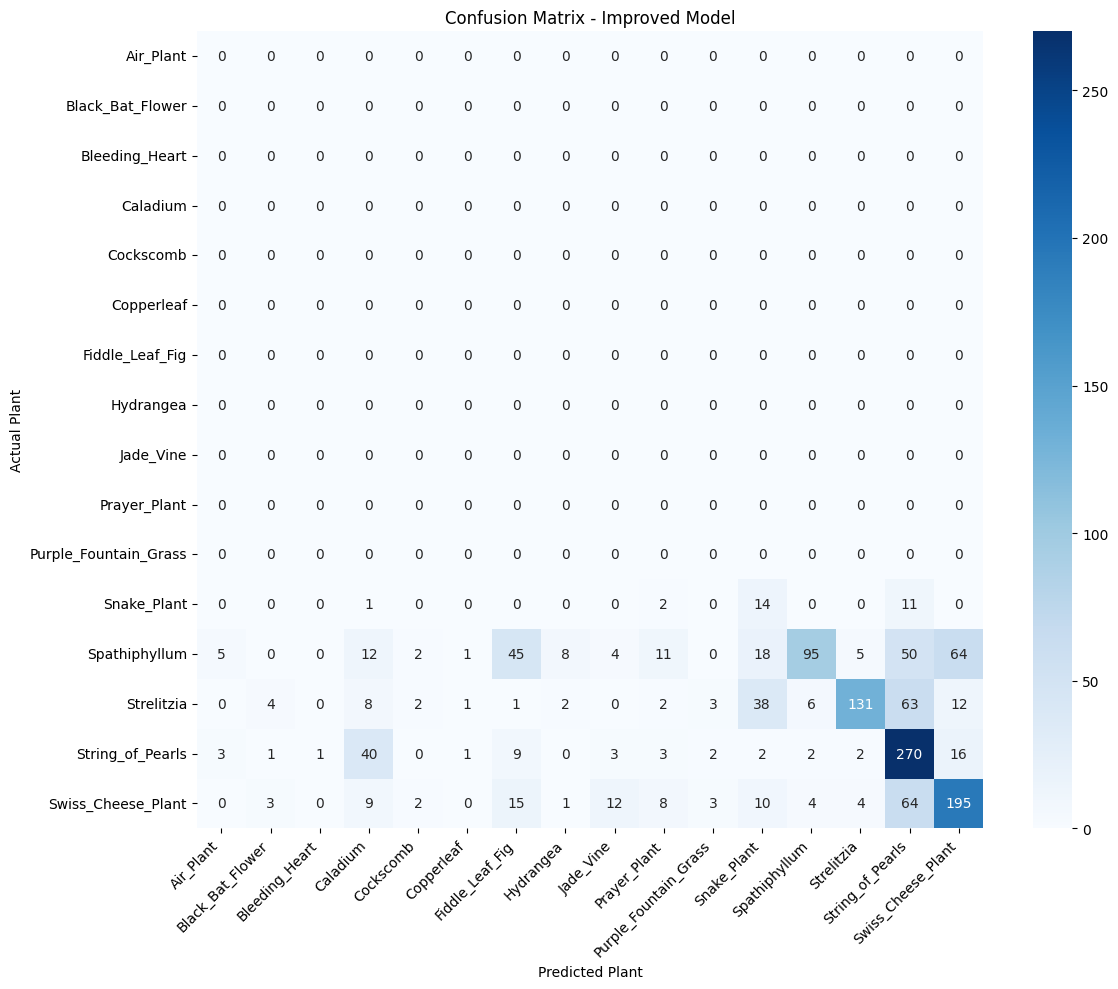

In [22]:
cm2 = confusion_matrix(y_true2, y_pred2, labels=unique_labels2)
plt.figure(figsize=(12, 10))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=final_names2, yticklabels=final_names2)
plt.title("Confusion Matrix - Improved Model")
plt.ylabel('Actual Plant')
plt.xlabel('Predicted Plant')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ran

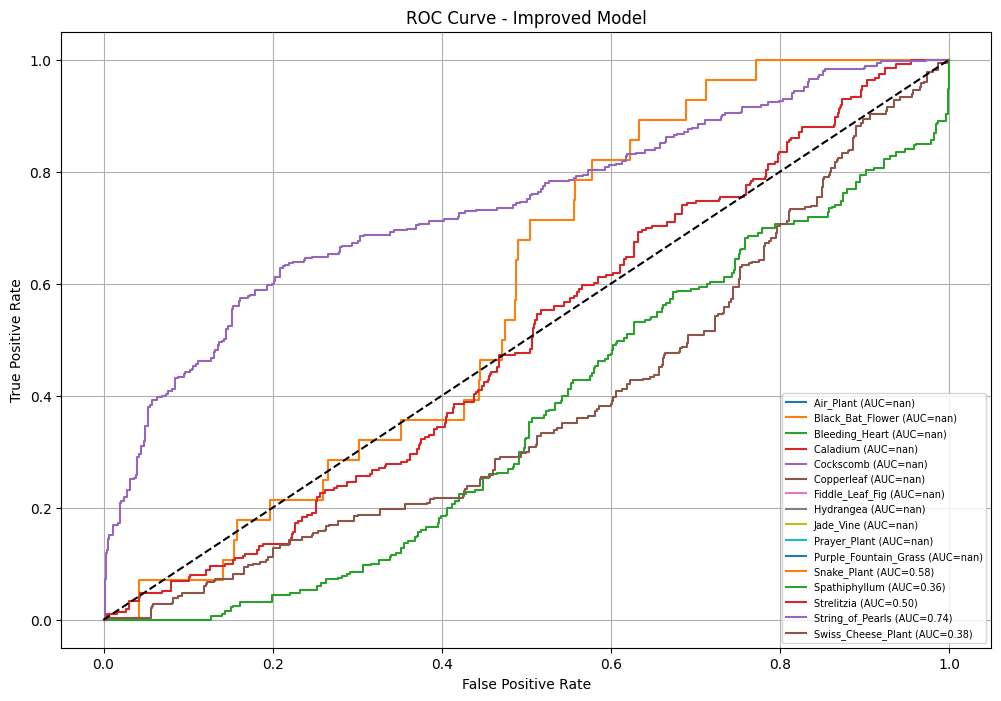

Overall AUC Score (Improved): nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [23]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

y_true2_bin = label_binarize(y_true2, classes=unique_labels2)

fpr2 = dict()
tpr2 = dict()
roc_auc2 = dict()

for i in range(len(unique_labels2)):
    fpr2[i], tpr2[i], _ = roc_curve(y_true2_bin[:, i], y_prob2[:, i])
    roc_auc2[i] = auc(fpr2[i], tpr2[i])

plt.figure(figsize=(12, 8))
for i in range(len(unique_labels2)):
    plt.plot(fpr2[i], tpr2[i], label=f"{final_names2[i]} (AUC={roc_auc2[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Improved Model")
plt.legend(loc="lower right", fontsize=7)
plt.grid()
plt.show()

try:
    auc_score2 = roc_auc_score(y_true2_bin, y_prob2[:, unique_labels2], multi_class='ovr')
    print(f"Overall AUC Score (Improved): {auc_score2:.4f}")
except:
    print("AUC Score: Could not compute due to missing classes")

In [24]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Load MobileNetV2 pretrained on ImageNet
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(180, 180, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze base

# Build on top of it
inputs = tf.keras.Input(shape=(180, 180, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names))(x)

transfer_model = tf.keras.Model(inputs, outputs)

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True)

print("Starting Transfer Learning training...")
history_transfer = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

transfer_model.save('my_plant_ai_transfer.keras')
print("✅ Transfer model saved!")

/tmp/ipykernel_1202/1777850513.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Starting Transfer Learning training...
Epoch 1/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 152s 794ms/step - accuracy: 0.1265 - loss: 3.1369 - val_accuracy: 0.2557 - val_loss: 2.4239
Epoch 2/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 93s 563ms/step - accuracy: 0.3440 - loss: 2.1993 - val_accuracy: 0.5069 - val_loss: 1.7594
Epoch 3/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 141s 558ms/step - accuracy: 0.5153 - loss: 1.6713 - val_accuracy: 0.6516 - val_loss: 1.3738
Epoch 4/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 143s 564ms/step - accuracy: 0.6081 - loss: 1.3737 - val_accuracy: 0.7113 - val_loss: 1.1372
Epoch 5/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 142s 563ms/step - accuracy: 0.6703 - loss: 1.1696 - val_accuracy: 0.7366 - val_loss: 1.0060
Epoch 6/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 145s 582ms/step - accuracy: 0.7021 - loss: 1.0328 - val_accuracy: 0.7657 - val_loss: 0.8960
Epoch 7/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 143s 587ms/step - accuracy: 0.7271 - loss: 0.9452 - val_accuracy: 0.7848 - val_lo